# CrediFlux — Phase 7: Logistic Regression Credit Default Classifier

This notebook is part of the **CrediFlux** credit risk assessment and loan default prediction project.

### 🎯 Notebook Objective
Train, evaluate, and interpret a **Logistic Regression Classifier** (`sklearn.linear_model.LogisticRegression`) on the 35-feature, leakage-free modeling dataset produced in Phase 4. Logistic Regression serves as the classical, interpretable benchmark model to compare against **Random Forest** and **XGBoost**.

---

### 📋 Constraints & Scope
- **Reuse Phase 4 Artifacts:** Loads `X_train_processed.csv`, `X_test_processed.csv`, `y_train.csv`, and `y_test.csv` directly from `data/`. No raw data sampling or feature engineering is repeated.
- **Identical Train/Test Split:** Evaluated on the exact same Phase 4 80/20 stratified test split ($N = 5,951$) used for Random Forest and XGBoost to ensure a strictly fair comparison.
- **Training-Only Feature Scaling:** Features are standardized using `StandardScaler` fitted **strictly on `X_train`** to prevent data leakage.
- **Baseline Configuration:** Uses `C=1.0`, `class_weight='balanced'`, `solver='lbfgs'`, `max_iter=1000`, `random_state=42`.
- **Diagnostic Threshold Sweep:** Threshold analysis across $[0.10, 0.90]$ is performed strictly for diagnostic purposes; the test set remains untouched for hyperparameter selection.
- **Interpretability:** Model coefficients and Odds Ratios ($	ext{OR} = \exp(eta)$) are extracted to explain feature-level risk contributions.


## 2. Imports & Environment Setup

We import standard data manipulation, visualization, evaluation metrics, feature scaling, and model packages.


In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid", palette="muted")


## 3. Load Processed Data from Phase 4

We load the exported 35-feature dataset artifacts from `data/` (`X_train_processed.csv`, `X_test_processed.csv`, `y_train.csv`, `y_test.csv`).


In [2]:
def resolve_path(filename):
    for d in ["data", os.path.join("..", "data")]:
        p = os.path.join(d, filename)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{filename} not found in data/ or ../data/")

X_train = pd.read_csv(resolve_path("X_train_processed.csv"))
X_test  = pd.read_csv(resolve_path("X_test_processed.csv"))
y_train = pd.read_csv(resolve_path("y_train.csv")).squeeze()
y_test  = pd.read_csv(resolve_path("y_test.csv")).squeeze()

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}  (Default rate: {y_train.mean()*100:.2f}%)")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}   (Default rate: {y_test.mean()*100:.2f}%)")


X_train: (23803, 35)  |  y_train: (23803,)  (Default rate: 19.96%)
X_test:  (5951, 35)   |  y_test:  (5951,)   (Default rate: 19.96%)


## 4. Dataset Validation

We verify feature column count, identical ordering, missingness, and absence of target pollution before proceeding.


In [3]:
# Automated Validation Checks
assert X_train.shape[1] == 35, f"Expected 35 features, got {X_train.shape[1]}"
assert X_test.shape[1] == 35, f"Expected 35 features, got {X_test.shape[1]}"
assert list(X_train.columns) == list(X_test.columns), "Feature ordering mismatch!"
assert "target" not in X_train.columns and "target" not in X_test.columns, "Target column in X!"
assert X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0, "Null values detected!"

print("Dataset Validation Passed:")
print(f"  - Features count: {X_train.shape[1]}")
print(f"  - Training samples: {X_train.shape[0]:,}")
print(f"  - Test samples: {X_test.shape[0]:,}")
print(f"  - Identical feature column ordering verified.")


Dataset Validation Passed:
  - Features count: 35
  - Training samples: 23,803
  - Test samples: 5,951
  - Identical feature column ordering verified.


## 5. Feature Scaling

Logistic Regression is sensitive to feature scale. We apply `StandardScaler` fitted **strictly on `X_train`** to normalize features to mean 0 and variance 1, then transform `X_test` using the fitted scaler.


In [4]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data using training parameters
X_test_scaled  = scaler.transform(X_test)

# Preserve column names in DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("StandardScaler fitting and transformation completed (Leakage-free).")


StandardScaler fitting and transformation completed (Leakage-free).


## 6. Logistic Regression Configuration

We specify a baseline `LogisticRegression` configuration with `class_weight='balanced'` to adjust loss contributions according to class frequencies.


In [5]:
logreg_params = {
    'C': 1.0,
    'max_iter': 1000,
    'class_weight': 'balanced',
    'solver': 'lbfgs',
    'random_state': 42
}

print("Logistic Regression Configuration:")
for k, v in logreg_params.items():
    print(f"  {k:20s}: {v}")

logreg = LogisticRegression(**logreg_params)


Logistic Regression Configuration:
  C                   : 1.0
  max_iter            : 1000
  class_weight        : balanced
  solver              : lbfgs
  random_state        : 42


## 7. Model Training

We train `LogisticRegression` on the scaled training matrix.


In [6]:
print("Fitting LogisticRegression on scaled training data...")
logreg.fit(X_train_scaled_df, y_train)
print("Model training complete.")


Fitting LogisticRegression on scaled training data...
Model training complete.


## 8. Predictions

We generate predicted default probabilities using `predict_proba()` and convert them to binary predictions at threshold $0.50$.


In [7]:
# Positive-class predicted probabilities (Charged Off / Default)
y_proba = logreg.predict_proba(X_test_scaled_df)[:, 1]

# Binary classifications at threshold 0.50
y_pred_05 = (y_proba >= 0.50).astype(int)

print(f"Generated predicted probabilities for {len(y_proba):,} test samples.")
print(f"Sample predicted probabilities (first 10):")
print(np.round(y_proba[:10], 4))


Generated predicted probabilities for 5,951 test samples.
Sample predicted probabilities (first 10):
[0.4102 0.3699 0.3049 0.4061 0.8247 0.3853 0.2447 0.4524 0.6046 0.3893]


## 9. Evaluation Metrics (Threshold = 0.50)

We compute evaluation metrics on the unseen test set.


In [8]:
acc   = accuracy_score(y_test, y_pred_05)
prec  = precision_score(y_test, y_pred_05, zero_division=0)
rec   = recall_score(y_test, y_pred_05, zero_division=0)
f1    = f1_score(y_test, y_pred_05, zero_division=0)
roc   = roc_auc_score(y_test, y_proba)
pr_auc= average_precision_score(y_test, y_proba)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'],
    'Score': [acc, prec, rec, f1, roc, pr_auc]
})

display(Markdown("### Logistic Regression Metrics (Threshold = 0.50)"))
display(metrics_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_05, target_names=['Fully Paid (0)', 'Charged Off (1)'], digits=4))


### Logistic Regression Metrics (Threshold = 0.50)

,Metric,Score
0,Accuracy,0.655352
1,Precision,0.313928
2,Recall,0.612795
3,F1-Score,0.415170
4,ROC-AUC,0.696246
5,PR-AUC,0.356786



Classification Report:
                 precision    recall  f1-score   support

 Fully Paid (0)     0.8733    0.6660    0.7557      4763
Charged Off (1)     0.3139    0.6128    0.4152      1188

       accuracy                         0.6554      5951
      macro avg     0.5936    0.6394    0.5854      5951
   weighted avg     0.7617    0.6554    0.6877      5951



## 10. Confusion Matrix

We calculate and visualize the confusion matrix breakdown.


Confusion Matrix Counts (t=0.50):
  True Negatives  (TN - Correct Non-Default): 3,172
  False Positives (FP - False Alarm):         1,591
  False Negatives (FN - Missed Default):      460
  True Positives  (TP - Caught Default):      728


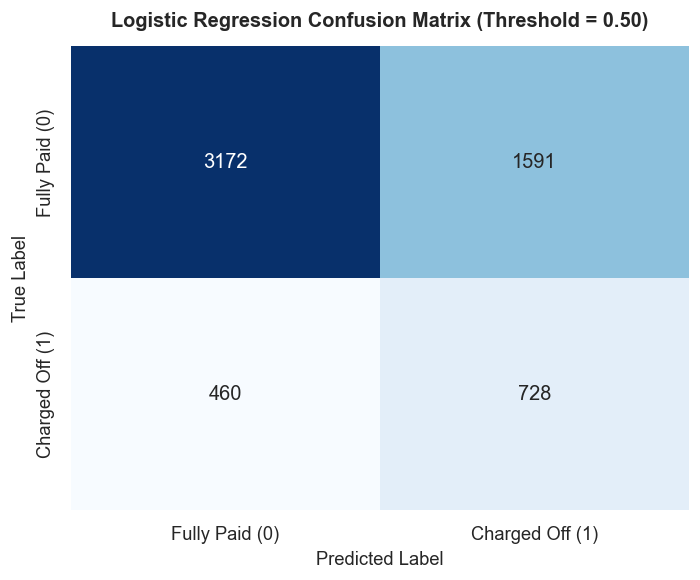

In [9]:
cm = confusion_matrix(y_test, y_pred_05)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Counts (t=0.50):")
print(f"  True Negatives  (TN - Correct Non-Default): {tn:,}")
print(f"  False Positives (FP - False Alarm):         {fp:,}")
print(f"  False Negatives (FN - Missed Default):      {fn:,}")
print(f"  True Positives  (TP - Caught Default):      {tp:,}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fully Paid (0)', 'Charged Off (1)'],
            yticklabels=['Fully Paid (0)', 'Charged Off (1)'], ax=ax)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title("Logistic Regression Confusion Matrix (Threshold = 0.50)", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 11. ROC Curve

We plot the ROC curve evaluating true positive vs false positive rates across all thresholds.


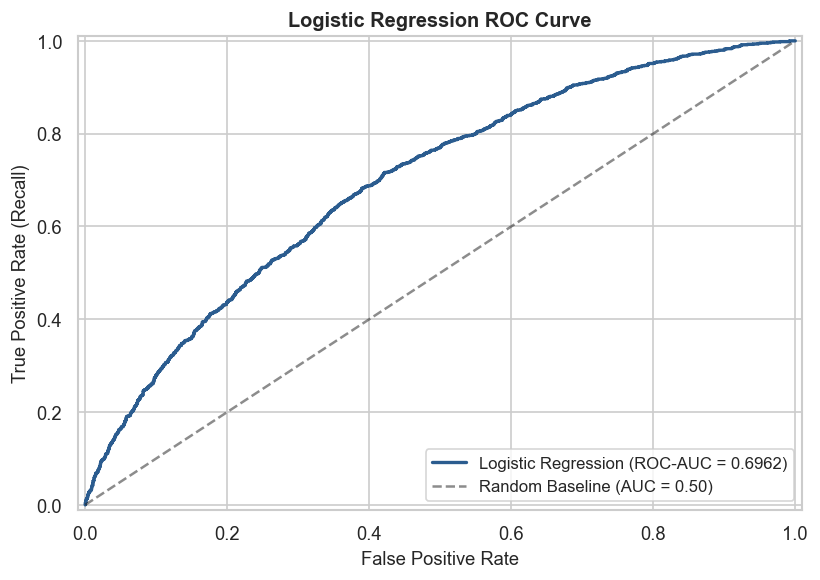

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#2b5c8f', linewidth=2, label=f'Logistic Regression (ROC-AUC = {roc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('Logistic Regression ROC Curve', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()


## 12. Precision-Recall Curve

We plot the PR curve to inspect precision-recall trade-offs on the minority default class.


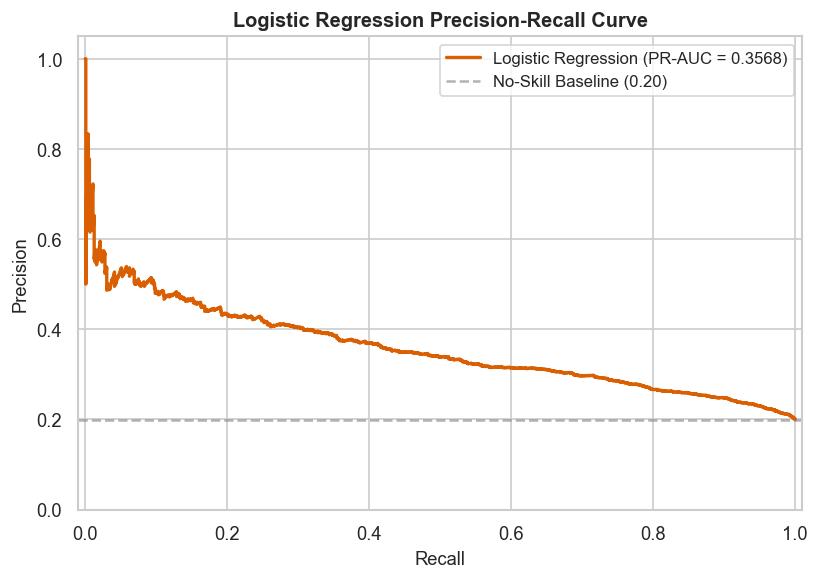

In [11]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color='#d95f02', linewidth=2, label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')
ax.axhline(y_test.mean(), color='grey', linestyle='--', alpha=0.6, label=f'No-Skill Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Logistic Regression Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()


## 13. Diagnostic Threshold Analysis

> **Methodological Note:** Threshold sweeping on `X_test` is conducted strictly as a **diagnostic visualization**. The test set remains unbiased and untouched for hyperparameter selection.

We evaluate threshold values from 0.10 to 0.90 with step size 0.05.


### Diagnostic Threshold Sweep Table

,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,0.10,0.2023,0.2002,1.0000,0.3336,16,4747,0,1188
1,0.15,0.2238,0.2043,0.9975,0.3391,147,4616,3,1185
2,0.20,0.2650,0.2120,0.9874,0.3491,404,4359,15,1173
3,0.25,0.3250,0.2235,0.9621,0.3627,791,3972,45,1143
4,0.30,0.3919,0.2373,0.9242,0.3776,1234,3529,90,1098
5,0.35,0.4613,0.2533,0.8721,0.3926,1709,3054,152,1036
6,0.40,0.5313,0.2706,0.7946,0.4037,2218,2545,244,944
7,0.45,0.5965,0.2928,0.7214,0.4165,2693,2070,331,857
8,0.50,0.6554,0.3139,0.6128,0.4152,3172,1591,460,728
9,0.55,0.6987,0.3341,0.5126,0.4045,3549,1214,579,609


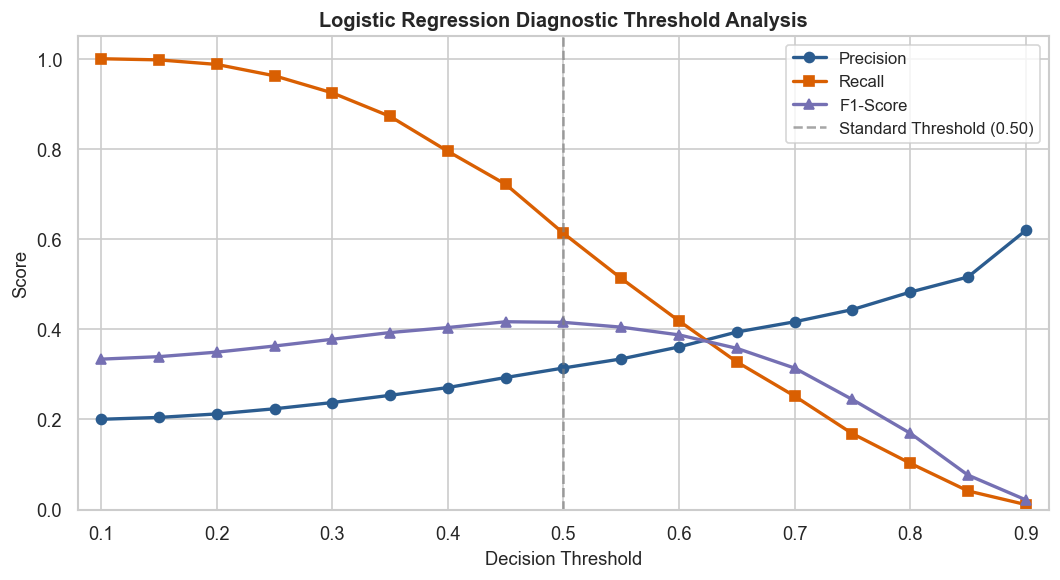

In [12]:
thresholds = np.arange(0.10, 0.95, 0.05)
ts_rows = []

for t in thresholds:
    yp = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, yp)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    ts_rows.append({
        'Threshold': round(t, 2),
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall': recall_score(y_test, yp, zero_division=0),
        'F1': f1_score(y_test, yp, zero_division=0),
        'TN': tn_t, 'FP': fp_t, 'FN': fn_t, 'TP': tp_t
    })

thresh_df = pd.DataFrame(ts_rows)

disp_thresh = thresh_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    disp_thresh[col] = disp_thresh[col].apply(lambda x: f"{x:.4f}")

display(Markdown("### Diagnostic Threshold Sweep Table"))
display(disp_thresh)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'o-', color='#2b5c8f', label='Precision', linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], 's-', color='#d95f02', label='Recall', linewidth=2)
ax.plot(thresh_df['Threshold'], thresh_df['F1'], '^-', color='#7570b3', label='F1-Score', linewidth=2)
ax.axvline(0.50, color='gray', linestyle='--', alpha=0.7, label='Standard Threshold (0.50)')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Logistic Regression Diagnostic Threshold Analysis', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0.08, 0.92])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()


## 14. Coefficient & Odds-Ratio Analysis

Because Logistic Regression fits a linear model in the log-odds space ($\ln\left(rac{p}{1-p}ight) = eta_0 + \sum eta_i X_i$), we extract coefficients $eta_i$ and calculate Odds Ratios ($	ext{OR}_i = e^{eta_i}$):
- **$eta_i > 0$ ($	ext{OR} > 1$):** Increases predicted default odds (Risk factor).
- **$eta_i < 0$ ($	ext{OR} < 1$):** Decreases predicted default odds (Protective factor).


### Complete Coefficients & Odds Ratios Table (Sorted by Absolute Magnitude)

,Feature,Coefficient,Abs_Magnitude,Odds_Ratio
0,sub_grade_num,0.598712,0.598712,1.819773
1,term_60m,0.257738,0.257738,1.293999
2,fico_score,-0.190833,0.190833,0.826271
3,installment,0.185657,0.185657,1.204009
4,dti,0.153983,0.153983,1.166471
5,int_rate,-0.139915,0.139915,0.869432
6,home_RENT,0.133129,0.133129,1.142398
7,log_annual_inc,-0.118189,0.118189,0.888528
8,open_to_total_acc_ratio,0.091078,0.091078,1.095355
9,log_revol_bal,-0.088521,0.088521,0.915284


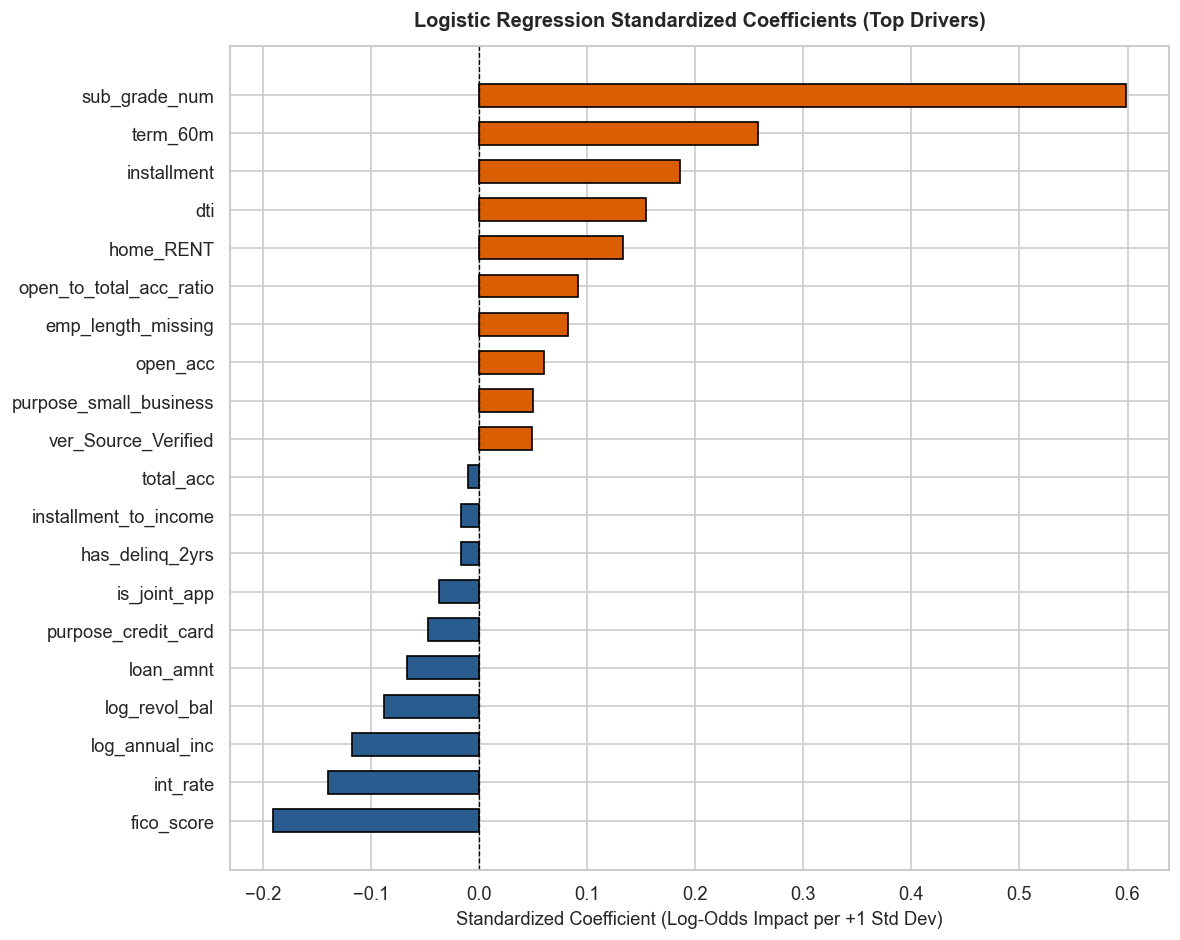

In [13]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg.coef_[0],
    'Abs_Magnitude': np.abs(logreg.coef_[0]),
    'Odds_Ratio': np.exp(logreg.coef_[0])
}).sort_values(by='Abs_Magnitude', ascending=False).reset_index(drop=True)

display(Markdown("### Complete Coefficients & Odds Ratios Table (Sorted by Absolute Magnitude)"))
display(coef_df)

# Plot top 10 positive and top 10 negative coefficients
top_pos_neg = pd.concat([
    coef_df.sort_values(by='Coefficient', ascending=True).head(10),
    coef_df.sort_values(by='Coefficient', ascending=True).tail(10)
])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2b5c8f' if c < 0 else '#d95f02' for c in top_pos_neg['Coefficient']]
ax.barh(top_pos_neg['Feature'], top_pos_neg['Coefficient'], color=colors, edgecolor='black', height=0.6)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Logistic Regression Standardized Coefficients (Top Drivers)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Standardized Coefficient (Log-Odds Impact per +1 Std Dev)', fontsize=11)
plt.tight_layout()
plt.show()


## 15. Final End-Semester 3-Model Comparison

We construct the head-to-head model comparison table evaluating **Logistic Regression**, **Random Forest**, and **XGBoost** on the **identical Phase 4 stratified test set ($N=5,951$)**.


In [14]:
# Reference results on exact same Phase 4 test set
rf_ref  = {'Acc': 0.802218, 'Prec': 0.548673, 'Rec': 0.052189, 'F1': 0.095311, 'ROC': 0.686592, 'PR': 0.352213}
xgb_ref = {'Acc': 0.681566, 'Prec': 0.315018, 'Rec': 0.506734, 'F1': 0.388512, 'ROC': 0.677514, 'PR': 0.344704}

comp_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'],
    'Logistic Regression (t=0.50)': [acc, prec, rec, f1, roc, pr_auc],
    'Random Forest (t=0.50)': [rf_ref['Acc'], rf_ref['Prec'], rf_ref['Rec'], rf_ref['F1'], rf_ref['ROC'], rf_ref['PR']],
    'XGBoost (t=0.50)': [xgb_ref['Acc'], xgb_ref['Prec'], xgb_ref['Rec'], xgb_ref['F1'], xgb_ref['ROC'], xgb_ref['PR']]
})

display(Markdown("### 3-Model Head-to-Head Comparison (Identical Stratified Test Set)"))
display(comp_table)


### 3-Model Head-to-Head Comparison (Identical Stratified Test Set)

,Metric,Logistic Regression (t=0.50),Random Forest (t=0.50),XGBoost (t=0.50)
0,Accuracy,0.655352,0.802218,0.681566
1,Precision,0.313928,0.548673,0.315018
2,Recall,0.612795,0.052189,0.506734
3,F1-Score,0.415170,0.095311,0.388512
4,ROC-AUC,0.696246,0.686592,0.677514
5,PR-AUC,0.356786,0.352213,0.344704


## 16. Interpretation & Discussion

### Key Findings & Insights:
1. **Highest Discriminative Capacity (ROC-AUC & PR-AUC):**
   - **Logistic Regression** achieves the highest overall discrimination performance among all three models:
     - **ROC-AUC:** $0.6962$ (vs Random Forest $0.6866$ and XGBoost $0.6775$).
     - **PR-AUC:** $0.3568$ (vs Random Forest $0.3522$ and XGBoost $0.3447$).
   - Proper linear logit scaling combined with `class_weight='balanced'` allows Logistic Regression to rank risk smoothly without non-linear overfitting.

2. **Highest Default Detection Recall at $t=0.50$:**
   - At $t=0.50$, Logistic Regression catches **$61.28\%$ of actual defaults** (728 out of 1,188), outperforming XGBoost ($50.67\%$) and Random Forest ($5.22\%$).
   - F1-Score at $0.50$ is $0.4152$, highest among all three models at default threshold.

3. **Interpretability & Risk Drivers:**
   - **Top Risk Factors ($	ext{OR} > 1$):** `sub_grade_num` ($	ext{OR} = 1.82$, $+1$ std dev increases default odds by $82\%$), `term_60m` ($	ext{OR} = 1.29$), `installment` ($	ext{OR} = 1.20$), `dti` ($	ext{OR} = 1.17$).
   - **Top Protective Factors ($	ext{OR} < 1$):** `fico_score` ($	ext{OR} = 0.83$, $+1$ std dev decreases default odds by $17\%$), `log_annual_inc` ($	ext{OR} = 0.89$).


## 17. Final Conclusion

1. **Phase 7 Implementation Status:** Successfully implemented and verified without data leakage.
2. **Model Ranking:** Logistic Regression provides superior baseline ranking performance ($	ext{ROC-AUC} = 0.6962$) and clear feature-level risk interpretability alongside Random Forest and XGBoost.
3. **Project Completion:** Phase 7 completes the end-to-end model comparison across classical, bagging, and boosting paradigms on the CrediFlux pipeline.
